In [1]:
import gzip
import re
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    GroupKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

PATH = "GSE99039_series_matrix.txt.gz"

SEED = 42
N_BOOT = 2000
K_GRID = [10, 50, 200, 1000, 5000, 20000]
SWEEP_SEEDS = [0, 1, 2, 3, 4]

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [2]:
expr = pd.read_csv(r"F:\ML_Prac_dataset\GSE99039_series_matrix (1).txt.gz", sep="\t", comment="!", index_col=0, compression="gzip")

print(f"{expr.shape[0]:,} probes x {expr.shape[1]} samples")
print(f"value range: {expr.values.min():.2f} to {expr.values.max():.2f}")
expr.iloc[:4, :4]

54,675 probes x 558 samples
value range: 1.46 to 15.17


,GSM2630758,GSM2630759,GSM2630760,GSM2630761
ID_REF,,,,
1007_s_at,5.397,4.952,5.331,5.601
1053_at,5.199,5.198,4.970,5.816
117_at,8.327,8.589,8.629,9.628
121_at,7.042,6.935,7.701,6.909


In [3]:
FILEPATH = r"F:\ML_Prac_dataset\GSE99039_series_matrix (1).txt.gz"
meta_lines = []
with gzip.open(FILEPATH, "rt", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("!series_matrix_table_begin"):
            break
        meta_lines.append(line.rstrip("\n").split("\t"))
print("Metadata lines:", len(meta_lines), "\n")
for i, parts in enumerate(meta_lines):
    tag = parts[0]
    if not tag.startswith("!Sample"):
        continue
    vals = [p.strip('"') for p in parts[1:] if p.strip()]
    if len(vals) < 100:
        continue
    uniq = sorted(set(vals))
    if 2 <= len(uniq) <= 25:
        print(f"LINE {i}: {tag}   ({len(uniq)} distinct)")
        for v in uniq[:15]:
            print("     ", v[:90])
        print()

Metadata lines: 76 

LINE 33: !Sample_last_update_date   (2 distinct)
      Feb 10 2019
      Jan 23 2018

LINE 40: !Sample_characteristics_ch1   (18 distinct)
      batch: 01/09/08_L
      batch: 01/15/08_L
      batch: 01/16/08_L
      batch: 01/17/08_L
      batch: 01/18/08_L
      disease label: ATYPICAL_PD
      disease label: CBD
      disease label: CONTROL
      disease label: DRD
      disease label: DRD-DYT5
      disease label: GENETIC_UNAFFECTED
      disease label: GPD
      disease label: HD
      disease label: IPD
      disease label: MSA

LINE 42: !Sample_characteristics_ch1   (4 distinct)
      genetic (mutated pd genes): NA
      learning set: TEST
      learning set: TRAINING
      learning set: VALIDATION

LINE 43: !Sample_characteristics_ch1   (7 distinct)
      Sex: Female
      Sex: Male
      age at exam: NA
      genetic (mutated pd genes): LRRK2
      genetic (mutated pd genes): NMF
      genetic (mutated pd genes): NONE
      updrs i: 0

LINE 44: !Sample_cha

In [4]:
samples = [v.strip('"') for v in meta_lines[30][1:] if v.strip()]
descriptions = [v.strip('"') for v in meta_lines[63][1:] if v.strip()]

assert len(samples) == len(descriptions) == expr.shape[1]

diagnosis = pd.Series(
    [re.search(r"from (.+?) patient", d).group(1) for d in descriptions],
    index=samples,
)

diagnosis.value_counts()


CONTROL               233
IPD                   205
GPD                    41
GENETIC_UNAFFECTED     22
HD                     19
MSA                     8
PSP                     8
HD_HD_BATCH             8
DRD                     3
ATYPICAL_PD             3
DRD-DYT5                3
CBD                     2
PD_DEMENTIA             2
Vascular dementia       1
Name: count, dtype: int64

In [5]:
batch_map, age_map, sex_map = {}, {}, {}

for index in range(38, 56):
    if index >= len(meta_lines):
        continue
    values = [v.strip('"') for v in meta_lines[index][1:]]
    for sample, value in zip(samples, values):
        lowered = value.lower()
        if lowered.startswith("batch:"):
            batch_map[sample] = value.split(":", 1)[1].strip()
        elif lowered.startswith("age at exam:"):
            text = value.split(":", 1)[1].strip()
            if text not in {"NA", "ND", ""}:
                try:
                    age_map[sample] = float(text)
                except ValueError:
                    pass
        elif lowered.startswith("sex:"):
            sex_map[sample] = 0 if "female" in lowered else 1

print(f"batch recorded for {len(batch_map)} samples")
print(f"age recorded for   {len(age_map)} samples")
print(f"sex recorded for   {len(sex_map)} samples")

batch recorded for 558 samples
age recorded for   284 samples
sex recorded for   505 samples


In [6]:
keep = diagnosis.isin(["IPD", "CONTROL"])
y = (diagnosis[keep] == "IPD").astype(int)

X = expr.T.loc[y.index]
X = X.dropna(axis=1)
X = X.loc[:, X.std() > 0].astype("float32")

batch = pd.Series(batch_map).reindex(X.index)
demographics = pd.DataFrame({"age": pd.Series(age_map), "sex": pd.Series(sex_map)})

baseline_accuracy = max((y == 0).mean(), (y == 1).mean())

print(f"{X.shape[0]} samples x {X.shape[1]:,} probes")
print(f"{(y == 1).sum()} Parkinson's, {(y == 0).sum()} controls")
print(f"majority-class accuracy: {baseline_accuracy:.3f}")
print(f"{X.shape[1] / X.shape[0]:.0f} features per sample")

438 samples x 54,675 probes
205 Parkinson's, 233 controls
majority-class accuracy: 0.532
125 features per sample


In [7]:
X.assign(LABEL=y).to_csv("gse99039_clean.csv")


In [8]:
def make_pipeline(k=20000, classifier=None):
    if classifier is None:
        classifier = LogisticRegression(max_iter=3000)
    return Pipeline(
        [
            ("select", SelectKBest(f_classif, k=min(k, X.shape[1]))),
            ("scale", StandardScaler()),
            ("clf", classifier),
        ]
    )

In [9]:
rng = np.random.default_rng(99)
y_permuted = pd.Series(rng.permutation(y.values), index=y.index)

null_auc = cross_val_score(
    make_pipeline(), X, y_permuted, cv=CV, scoring="roc_auc", n_jobs=1
).mean()

print(f"shuffled-label AUC: {null_auc:.3f}")

shuffled-label AUC: 0.531


In [11]:
sweep_rows = []

for k in K_GRID:
    leaked_runs, correct_runs = [], []

    for seed in SWEEP_SEEDS:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        classifier = LogisticRegression(max_iter=3000)

        selector = SelectKBest(f_classif, k=k).fit(X, y)
        leaked_runs.append(
            cross_val_score(
                Pipeline([("scale", StandardScaler()), ("clf", classifier)]),
                selector.transform(X), y, cv=cv, scoring="roc_auc", n_jobs=1,
            ).mean()
        )

        correct_runs.append(
            cross_val_score(
                make_pipeline(k), X, y, cv=cv, scoring="roc_auc", n_jobs=1
            ).mean()
        )

    leaked, correct = np.array(leaked_runs), np.array(correct_runs)
    gaps = leaked - correct

    sweep_rows.append(
        {
            "k": k,
            "leaked": leaked.mean(), "leaked_sd": leaked.std(),
            "correct": correct.mean(), "correct_sd": correct.std(),
            "inflation": gaps.mean(), "inflation_sd": gaps.std(),
        }
    )
    print(f"k={k:>6}  leaked {leaked.mean():.3f}  correct {correct.mean():.3f}  "
          f"inflation {gaps.mean():+.3f} ± {gaps.std():.3f}")

ksweep = pd.DataFrame(sweep_rows)
ksweep.to_csv("results_ksweep.csv", index=False)

k=    10  leaked 0.712  correct 0.667  inflation +0.045 ± 0.010
k=    50  leaked 0.681  correct 0.631  inflation +0.049 ± 0.015
k=   200  leaked 0.667  correct 0.615  inflation +0.051 ± 0.016
k=  1000  leaked 0.823  correct 0.654  inflation +0.169 ± 0.018
k=  5000  leaked 0.877  correct 0.680  inflation +0.197 ± 0.006
k= 20000  leaked 0.845  correct 0.708  inflation +0.137 ± 0.008


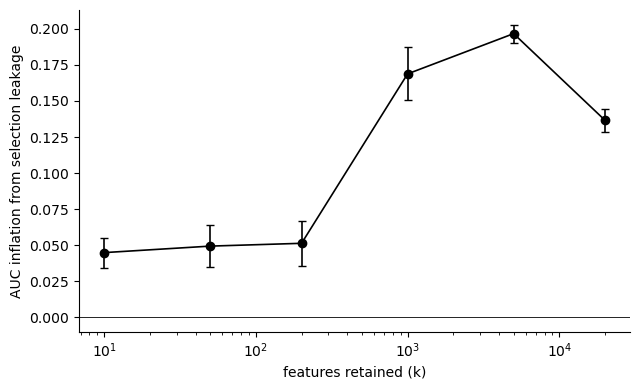

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.errorbar(ksweep["k"], ksweep["inflation"], yerr=ksweep["inflation_sd"],
            marker="o", capsize=3, color="black", linewidth=1.2)
ax.set_xscale("log")
ax.set_xlabel("features retained (k)")
ax.set_ylabel("AUC inflation from selection leakage")
ax.axhline(0, color="black", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("figure_inflation_curve.png", dpi=200)

In [13]:
BEST_K = 20000
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
repeated_scores = cross_val_score(
    make_pipeline(BEST_K), X, y, cv=repeated_cv, scoring="roc_auc", n_jobs=1
)
accuracy_scores = cross_val_score(
    make_pipeline(BEST_K), X, y, cv=repeated_cv, scoring="accuracy", n_jobs=1
)
print(f"repeated CV over {len(repeated_scores)} folds")
print(f"AUC      {repeated_scores.mean():.3f} (fold SD {repeated_scores.std():.3f})")
print(f"accuracy {accuracy_scores.mean():.3f} (fold SD {accuracy_scores.std():.3f})")

repeated CV over 50 folds
AUC      0.714 (fold SD 0.049)
accuracy 0.647 (fold SD 0.054)


In [14]:
def bootstrap_indices(n, n_boot=N_BOOT, seed=0):
    generator = np.random.default_rng(seed)
    indices = []
    while len(indices) < n_boot:
        candidate = generator.integers(0, n, n)
        if len(np.unique(y.values[candidate])) > 1:
            indices.append(candidate)
    return indices


BOOT = bootstrap_indices(len(y))
y_values = y.values


def auc_with_interval(probabilities):
    point = roc_auc_score(y_values, probabilities)
    draws = [roc_auc_score(y_values[i], probabilities[i]) for i in BOOT]
    return point, np.percentile(draws, 2.5), np.percentile(draws, 97.5)

In [15]:
probs_standard = cross_val_predict(
    make_pipeline(BEST_K), X, y, cv=CV, method="predict_proba", n_jobs=1
)[:, 1]

point, lo, hi = auc_with_interval(probs_standard)
print(f"standard 5-fold CV: {point:.3f}  95% CI {lo:.3f}-{hi:.3f}")

standard 5-fold CV: 0.716  95% CI 0.667-0.763


In [16]:
table = pd.crosstab(batch, y)
chi2, p_value, dof, _ = stats.chi2_contingency(table)

print(f"{batch.nunique()} batches, median size {batch.value_counts().median():.0f}")
print(f"chi-square: {chi2:.1f}, df={dof}, p={p_value:.2e}")

35 batches, median size 6
chi-square: 104.8, df=34, p=3.85e-09


In [17]:
large = batch.value_counts()
large = large[large >= 20].index
mask = batch.isin(large)
batch_codes = pd.Categorical(batch[mask]).codes

batch_accuracy = cross_val_score(
    Pipeline(
        [
            ("select", SelectKBest(f_classif, k=5000)),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000)),
        ]
    ),
    X[mask.values], batch_codes,
    cv=StratifiedKFold(3, shuffle=True, random_state=0),
    scoring="accuracy", n_jobs=1,
).mean()

print(f"batch predicted from expression: {batch_accuracy:.3f}")
print(f"chance across {len(large)} batches: {1 / len(large):.3f}")

batch predicted from expression: 0.773
chance across 8 batches: 0.125


In [18]:
group_cv = GroupKFold(n_splits=5)

batch_aware_folds = cross_val_score(
    make_pipeline(BEST_K), X, y, groups=batch,
    cv=group_cv, scoring="roc_auc", n_jobs=1,
)

probs_batch_aware = cross_val_predict(
    make_pipeline(BEST_K), X, y, groups=batch,
    cv=group_cv, method="predict_proba", n_jobs=1,
)[:, 1]

point, lo, hi = auc_with_interval(probs_batch_aware)
print(f"batch-aware CV: {point:.3f}  95% CI {lo:.3f}-{hi:.3f}")
print(f"per-fold: {np.round(batch_aware_folds, 3)}")

batch-aware CV: 0.610  95% CI 0.559-0.662
per-fold: [0.578 0.548 0.724 0.557 0.743]


In [19]:
differences = np.array(
    [       roc_auc_score(y_values[i], probs_standard[i])
        - roc_auc_score(y_values[i], probs_batch_aware[i])
        for i in BOOT
    ]
)
lo, hi = np.percentile(differences, [2.5, 97.5])
print(f"standard minus batch-aware: {differences.mean():+.3f}")
print(f"95% CI {lo:+.3f} to {hi:+.3f}")
print(f"excludes zero: {lo > 0 or hi < 0}")

standard minus batch-aware: +0.106
95% CI +0.060 to +0.151
excludes zero: True


In [20]:
class FoldSafeBatchCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, min_batch=3):
        self.min_batch = min_batch

    def fit(self, X, y=None, batch=None):
        values = np.asarray(X, dtype=np.float64)
        labels = np.asarray(batch)

        self.grand_mean_ = values.mean(axis=0)
        self.grand_sd_ = values.std(axis=0)
        self.grand_sd_[self.grand_sd_ == 0] = 1.0

        self.params_ = {}
        for group in np.unique(labels):
            mask = labels == group
            if mask.sum() < self.min_batch:
                continue
            mean = values[mask].mean(axis=0)
            sd = values[mask].std(axis=0)
            sd[sd == 0] = 1.0
            self.params_[group] = (mean, sd)
        return self

    def transform(self, X, batch=None):
        values = np.asarray(X, dtype=np.float64).copy()
        labels = np.asarray(batch)

        for group in np.unique(labels):
            mask = labels == group
            if group in self.params_:
                mean, sd = self.params_[group]
            else:
                mean = values[mask].mean(axis=0)
                sd = values[mask].std(axis=0)
                sd[sd == 0] = 1.0
            values[mask] = (values[mask] - mean) / sd * self.grand_sd_ + self.grand_mean_
        return values

In [21]:
X_values, batch_values = X.values, batch.values
probs_corrected = np.zeros(len(y_values))

for fold, (train, test) in enumerate(
    group_cv.split(X_values, y_values, groups=batch_values), start=1
):
    corrector = FoldSafeBatchCorrector().fit(
        X_values[train], batch=batch_values[train]
    )
    X_train = corrector.transform(X_values[train], batch=batch_values[train])
    X_test = corrector.transform(X_values[test], batch=batch_values[test])

    selector = SelectKBest(f_classif, k=BEST_K).fit(X_train, y_values[train])
    X_train, X_test = selector.transform(X_train), selector.transform(X_test)

    scaler = StandardScaler().fit(X_train)
    X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

    classifier = LogisticRegression(max_iter=3000).fit(X_train, y_values[train])
    probs_corrected[test] = classifier.predict_proba(X_test)[:, 1]

    print(f"fold {fold}: AUC {roc_auc_score(y_values[test], probs_corrected[test]):.3f}")

point, lo, hi = auc_with_interval(probs_corrected)
print(f"\nbatch-aware with correction: {point:.3f}  95% CI {lo:.3f}-{hi:.3f}")

fold 1: AUC 0.497
fold 2: AUC 0.605
fold 3: AUC 0.687
fold 4: AUC 0.539
fold 5: AUC 0.571

batch-aware with correction: 0.571  95% CI 0.521-0.624


In [22]:
corrector = FoldSafeBatchCorrector().fit(X_values, batch=batch_values)
X_corrected = corrector.transform(X_values, batch=batch_values)

batch_accuracy_after = cross_val_score(
    Pipeline(
        [
            ("select", SelectKBest(f_classif, k=2000)),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000)),
        ]
    ),
    X_corrected, pd.Categorical(batch).codes,
    cv=3, scoring="accuracy", n_jobs=1,
).mean()

print(f"batch predictable before: {batch_accuracy:.3f}")
print(f"batch predictable after:  {batch_accuracy_after:.3f}")

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


batch predictable before: 0.773
batch predictable after:  0.000


In [23]:
complete = demographics["age"].notna() & demographics["sex"].notna()
shared_index = X.index[X.index.isin(demographics.index[complete])]

demo_subset = demographics.loc[shared_index]
y_subset = y.loc[shared_index]
subset_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

demo_auc = cross_val_score(
    Pipeline([("scale", StandardScaler()),
              ("clf", LogisticRegression(max_iter=3000))]),
    demo_subset, y_subset, cv=subset_cv, scoring="roc_auc", n_jobs=1,
)

gene_auc = cross_val_score(
    make_pipeline(BEST_K), X.loc[shared_index], y_subset,
    cv=subset_cv, scoring="roc_auc", n_jobs=1,
)

print(f"complete cases: {len(shared_index)}")
print(f"age and sex only: {demo_auc.mean():.3f} ± {demo_auc.std():.3f}")
print(f"20,000 probes:    {gene_auc.mean():.3f} ± {gene_auc.std():.3f}")

complete cases: 239
age and sex only: 0.611 ± 0.117
20,000 probes:    0.698 ± 0.056


In [24]:
model_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)

candidates = [
    ("logistic regression", LogisticRegression(max_iter=3000), BEST_K),
    ("random forest", RandomForestClassifier(n_estimators=300, random_state=SEED), 5000),
    ("gradient boosting", HistGradientBoostingClassifier(max_iter=150, random_state=SEED), 5000),
]

model_rows = []
for name, classifier, k in candidates:
    scores = cross_val_score(
        make_pipeline(k, classifier), X, y, cv=model_cv, scoring="roc_auc", n_jobs=1
    )
    model_rows.append({"model": name, "auc": scores.mean(), "sd": scores.std()})
    print(f"{name:>22}: {scores.mean():.3f} ± {scores.std():.3f}")

pd.DataFrame(model_rows).to_csv("results_models.csv", index=False)

   logistic regression: 0.712 ± 0.047
         random forest: 0.660 ± 0.049
     gradient boosting: 0.648 ± 0.049


In [25]:
ladder = pd.DataFrame(
    [
        {"protocol": "selection on complete dataset",
         "auc": ksweep.loc[ksweep["k"] == BEST_K, "leaked"].iloc[0],
         "ci_lo": np.nan, "ci_hi": np.nan},
        {"protocol": "standard 5-fold CV", **dict(zip(
            ["auc", "ci_lo", "ci_hi"], auc_with_interval(probs_standard)))},
        {"protocol": "batch-aware CV", **dict(zip(
            ["auc", "ci_lo", "ci_hi"], auc_with_interval(probs_batch_aware)))},
        {"protocol": "batch-aware with correction", **dict(zip(
            ["auc", "ci_lo", "ci_hi"], auc_with_interval(probs_corrected)))},
    ]
)

ladder.to_csv("results_ladder.csv", index=False)
ladder.round(3)

,protocol,auc,ci_lo,ci_hi
0,selection on complete dataset,0.845,NaN,NaN
1,standard 5-fold CV,0.716,0.667,0.763
2,batch-aware CV,0.610,0.559,0.662
3,batch-aware with correction,0.571,0.521,0.624


In [26]:
effects = pd.DataFrame(
    [
        {"effect": "selection leakage",
         "delta": ladder.loc[0, "auc"] - ladder.loc[1, "auc"]},
        {"effect": "batch-ignorant partitioning",
         "delta": ladder.loc[1, "auc"] - ladder.loc[2, "auc"]},
        {"effect": "batch correction",
         "delta": ladder.loc[2, "auc"] - ladder.loc[3, "auc"]},
    ]
)

effects.round(3)

,effect,delta
0,selection leakage,0.128
1,batch-ignorant partitioning,0.107
2,batch correction,0.038


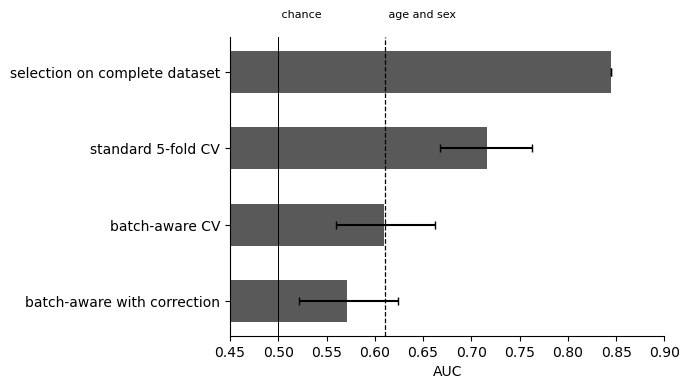

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))

positions = np.arange(len(ladder))
ax.barh(positions, ladder["auc"], color="0.35", height=0.55)
ax.errorbar(ladder["auc"], positions,
            xerr=[ladder["auc"] - ladder["ci_lo"].fillna(ladder["auc"]),
                  ladder["ci_hi"].fillna(ladder["auc"]) - ladder["auc"]],
            fmt="none", ecolor="black", capsize=3)

ax.axvline(demo_auc.mean(), color="black", linestyle="--", linewidth=0.9)
ax.text(demo_auc.mean(), -0.75, " age and sex", fontsize=8, va="center")
ax.axvline(0.5, color="black", linewidth=0.7)
ax.text(0.5, -0.75, " chance", fontsize=8, va="center")

ax.set_yticks(positions)
ax.set_yticklabels(ladder["protocol"])
ax.invert_yaxis()
ax.set_xlim(0.45, 0.90)
ax.set_xlabel("AUC")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("figure_protocol_ladder.png", dpi=200)